In [17]:
import sys
import os
sys.path.append(os.path.abspath("../Src"))
from lcg import lcg
from random_walk import random_walk
import numpy as np
import matplotlib.pyplot as plt


# Random Walk

Starting from the random variable $X$:

$$
\begin{cases}
X = 1 \quad &\text{with probability} \quad p \\
X = -1 \quad &\text{with probability} \quad 1 - p
\end{cases}
$$

We generate a random walk by choosing $p = 0.5$.

Thus, we define a stochastic process $\{S_n, n \geq 0\}$ such that:

- $S_0 = 0$
- $S_n = \sum_{i=1}^{n} X_i$ for $n > 0$

where the random variables $X_n$, for $n > 0$, are identically distributed as $X$ and are independent of each other.

Recall that the variance of the random variable $S_n$ is:

$$
\mathrm{Var}(S_n) = 4np(1-p)
$$

In our case ($p = 0.5$), we obtain:

$$
\mathrm{Var}(S_n) = n \qquad (p = 0.5)
$$

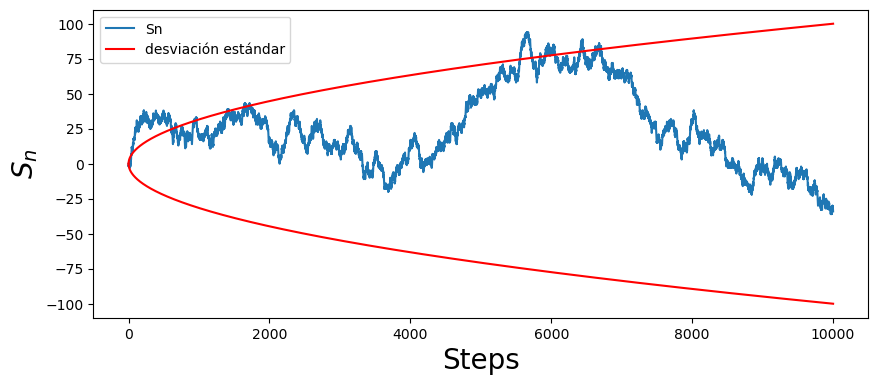

In [24]:
N=10000
Sn=random_walk(N=N, seed=1, a=1664525, m=2**32)

ones = np.append(0,np.ones(N))
var=np.cumsum(ones)
st_dev= np.sqrt(var)

plt.figure(figsize=(10,4))

plt.plot(Sn,label = 'Sn')
plt.plot(st_dev,color='red', label = 'desviación estándar')
plt.plot(-st_dev,color='red')

plt.xlabel('Steps',fontsize=20)
plt.ylabel('$S_n$',fontsize=20)

plt.legend()
plt.show()

## Distribution of the Final Positions

In this experiment, we simulate a large number of independent random walks and analyze their final positions. Each walk is constructed as the sum of independent and identically distributed random variables $X_i \in \{-1, 1\}$ with equal probability.

For each realization, we record the final position:
$$
S_n = \sum_{i=1}^{n} X_i
$$

According to the Central Limit Theorem, as the number of steps $n$ increases, the distribution of $S_n$ (properly scaled) converges to a normal distribution. In particular, since $\mathbb{E}[X_i] = 0$ and $\mathrm{Var}(X_i) = 1$, we have:
$$
\mathrm{Var}(S_n) = n
$$

This implies that the typical magnitude of $S_n$ grows like $\sqrt{n}$, which is represented in the plot by the curves corresponding to the standard deviation.

By simulating many independent random walks and collecting their final positions, we can empirically observe this result. The histogram of the final points shows that their distribution approaches a bell-shaped curve, consistent with a normal distribution centered at zero.

This provides a numerical illustration of the Central Limit Theorem in the context of random walks.

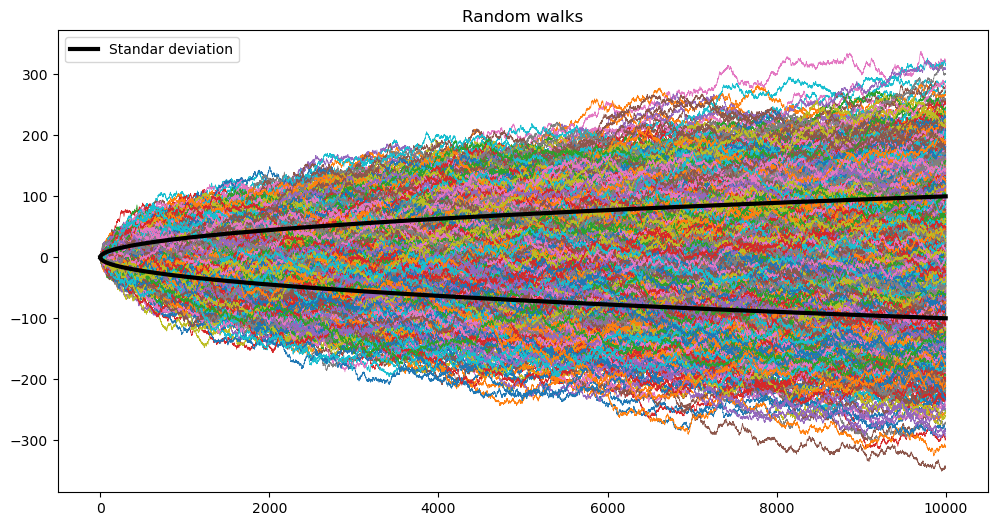

In [33]:
num_walks=2500
plt.figure(figsize=(12,6))
final_points = []

for k in range(num_walks):
  individual_walk = random_walk(N=N, seed=k+1, a=1664525, m=2**32)
  plt.plot(individual_walk,linewidth =0.5)
  final_points.append(individual_walk[-1])

plt.plot(st_dev,color='black',linewidth = 3,label = 'Standar deviation')
plt.plot(-st_dev,color='black',linewidth = 3)

#Dibujamos todo junto
plt.title('Random walks')
plt.legend(loc='upper left')
plt.show()

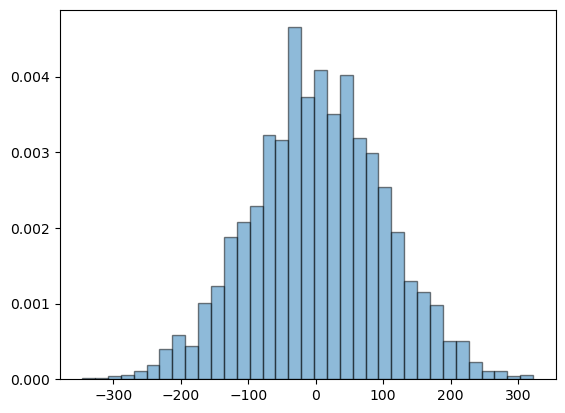

In [34]:
plt.hist(final_points,bins='auto',alpha=0.5,density='True',edgecolor='black')
plt.show()